<a href="https://colab.research.google.com/github/cedizen/amazon_dataset/blob/main/amazon_dataset_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Introduction:** The objective of this notebook is to perform an in-depth Exploratory Data Analaysis (EDA) of the dataset in order to understand customer behavior, product performance, sales pattern and operational characteritics. By generating descriptive statistics and visualizations, this analysis aims to identify meaningful trends, anomalies and relationships that can support future business decisions and modeling tasks.

# Table of Contents
1. Data Loading
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Statistical Tests
6. Machine Learning Models
7. Results & Interpretation
8. Conclusion

In [ ]:
# Core
import numpy as np
import pandas as pd
import math

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# stats
from scipy.stats import spearmanr

# Models
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import r2_score, mean_absolute_error

# **1. Data loading**

In [ ]:
df_amazon = pd.read_csv("Amazon.csv")

In [ ]:
df_amazon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   OrderID        100000 non-null  object 
 1   OrderDate      100000 non-null  object 
 2   CustomerID     100000 non-null  object 
 3   CustomerName   100000 non-null  object 
 4   ProductID      100000 non-null  object 
 5   ProductName    100000 non-null  object 
 6   Category       100000 non-null  object 
 7   Brand          100000 non-null  object 
 8   Quantity       100000 non-null  int64  
 9   UnitPrice      100000 non-null  float64
 10  Discount       100000 non-null  float64
 11  Tax            100000 non-null  float64
 12  ShippingCost   100000 non-null  float64
 13  TotalAmount    100000 non-null  float64
 14  PaymentMethod  100000 non-null  object 
 15  OrderStatus    100000 non-null  object 
 16  City           100000 non-null  object 
 17  State          100000 non-null

In [ ]:
df_amazon.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [ ]:
df_amazon.describe()

,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479
std,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332
min,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000


# **2. Data cleaning**

In [ ]:
df_amazon.isnull().sum()

,0
OrderID,0
OrderDate,0
CustomerID,0
CustomerName,0
ProductID,0
ProductName,0
Category,0
Brand,0
Quantity,0
UnitPrice,0


In [ ]:
df_amazon.dropna(inplace=True)

In [ ]:
df_amazon.duplicated().sum()

np.int64(0)

In [ ]:
for col in df_amazon.columns:
  print(df_amazon[col].value_counts())

OrderID
ORD0099984    1
ORD0099983    1
ORD0099982    1
ORD0099981    1
ORD0099980    1
             ..
ORD0000005    1
ORD0000004    1
ORD0000003    1
ORD0000002    1
ORD0000001    1
Name: count, Length: 100000, dtype: int64
OrderDate
2022-04-28    85
2021-01-21    82
2021-09-09    79
2022-01-31    79
2020-05-28    78
              ..
2023-09-17    36
2021-02-14    36
2022-10-31    35
2023-05-06    34
2020-12-17    31
Name: count, Length: 1825, dtype: int64
CustomerID
CUST037103    10
CUST023748    10
CUST009614     9
CUST005654     9
CUST031337     9
              ..
CUST011195     1
CUST044331     1
CUST011350     1
CUST030828     1
CUST030740     1
Name: count, Length: 43233, dtype: int64
CustomerName
Karan Joshi     556
Arjun Kumar     553
Pooja Kapoor    552
Rohit Gupta     547
Vihaan Singh    544
               ... 
Kabir Patel     454
Aman Sharma     453
Sneha Singh     450
Sunita Reddy    440
Vikas Gupta     436
Name: count, Length: 200, dtype: int64
ProductID
P00019    2098
P

In [ ]:
df_amazon["OrderDate"].value_counts()

,count
OrderDate,
2022-04-28,85
2021-01-21,82
2021-09-09,79
2022-01-31,79
2020-05-28,78
...,...
2023-09-17,36
2021-02-14,36
2022-10-31,35


# **Outliers detections**

In [ ]:
numerical_columns = df_amazon.select_dtypes(include="number").columns.tolist()

Now we can see the distribution of main numerical features as we are mainly looking for outliers

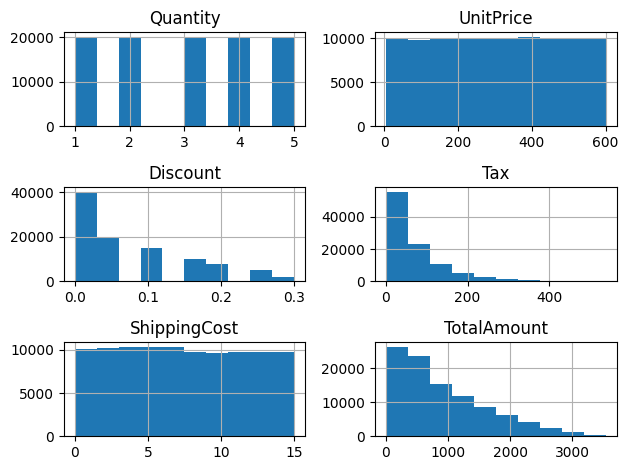

In [ ]:
df_amazon[numerical_columns].hist()
plt.tight_layout()
plt.show()

Discount, Tax and Total Amount seem to be highly left skewed while others are more well distributed

Let's see how boxplots behave

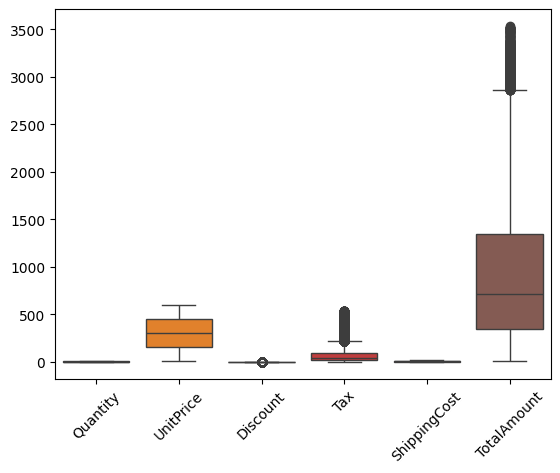

In [ ]:
sns.boxplot(df_amazon[numerical_columns])
plt.xticks(rotation=45)
plt.show()

The boxplot visualisation confirms that Tax and Total Amount show a lot of outliers.

But are there any extreme outliers ?

In [ ]:
def outliers_detection(series, mutliplicator=1.5):
  Q1 = series.quantile(0.25)
  Q3 = series.quantile(0.75)

  iqr = Q3 - Q1
  upper_bound = Q3 + mutliplicator * iqr
  lower_bound = Q1 - mutliplicator * iqr

  extreme_outliers = (series < lower_bound) | (series > upper_bound)
  return extreme_outliers

## **Normal outliers ?**

In [ ]:
outliers_rs = outliers_detection(df_amazon["TotalAmount"])

In [ ]:
outliers_count = (outliers_rs == True).sum()
print(f"There are {outliers_count} outliers either \
{outliers_count / df_amazon["TotalAmount"].count() * 100:.2f}% of the total rows")

There are 1360 outliers either 1.36% of the total rows


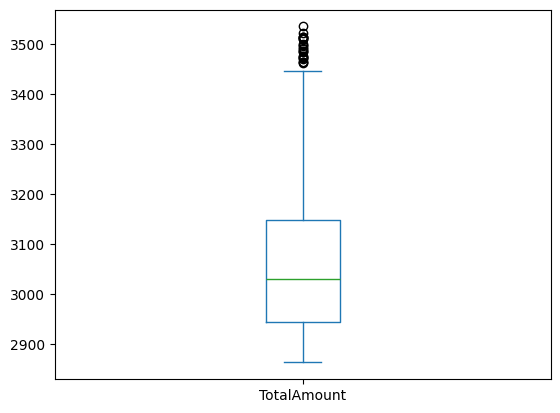

In [ ]:
if outliers_count > 0:
  df_amazon[outliers_rs]["TotalAmount"].plot(kind="box")
  plt.show()
else:
  print("No outliers to plot")

## **Extreme outliers ?**

In [ ]:
extreme_outliers_rs = outliers_detection(df_amazon["TotalAmount"], mutliplicator=3)

In [ ]:
extreme_outliers_count = (extreme_outliers_rs == True).sum()
print(f"There are {extreme_outliers_count} extreme outliers")

There are 0 extreme outliers


In [ ]:
if extreme_outliers_count > 0:
  df_amazon[extreme_outliers_rs]["TotalAmount"].plot(kind="box")
else:
  print("No extreme outliers to plot")

No extreme outliers to plot


# **Correlations between data**

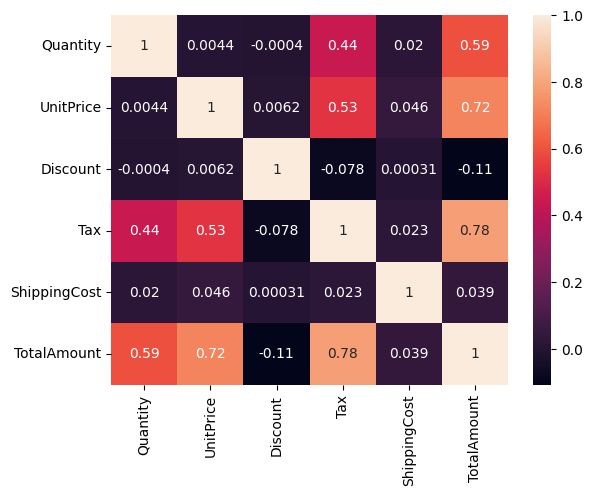

In [ ]:
sns.heatmap(df_amazon[numerical_columns].corr(), annot=True)
plt.show()

In [ ]:
relevant_features_corr = df_amazon[numerical_columns].corr().columns[(df_amazon[numerical_columns].corr().abs() > 0.5).sum() > 1]

In [ ]:
print(f"The next following features seems to have a certain correlation level:")
for c in relevant_features_corr:
  print(f"- {c}")

The next following features seems to have a certain correlation level:
- Quantity
- UnitPrice
- Tax
- TotalAmount


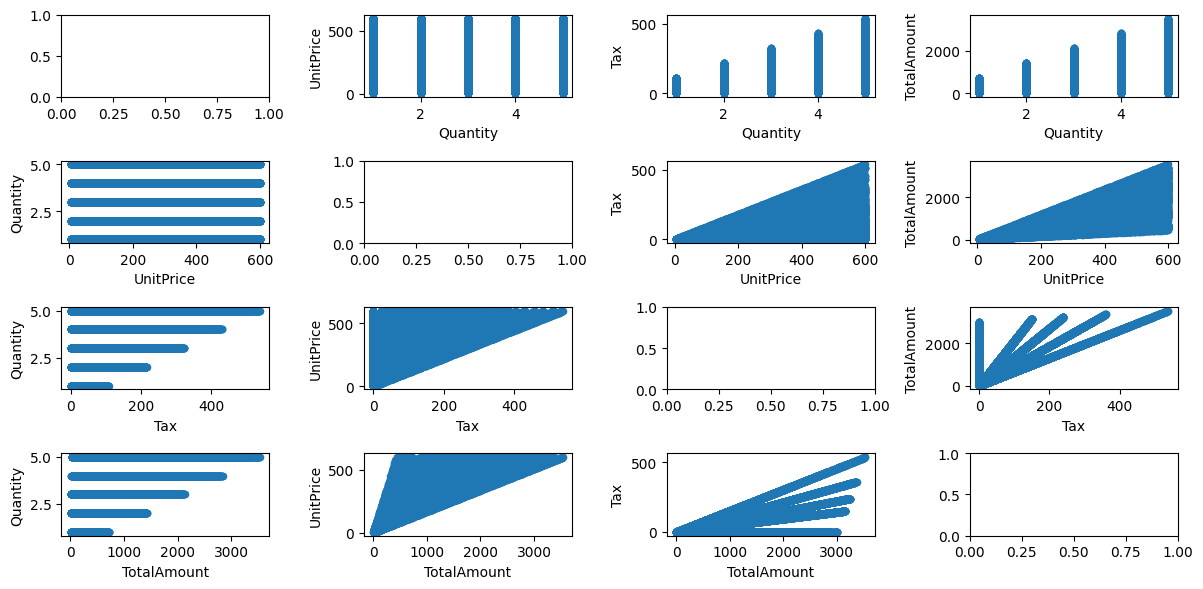

In [ ]:
n = len(relevant_features_corr)
fig, axes = plt.subplots(n, n, figsize=(12, 6))
for i, col1 in enumerate(relevant_features_corr):
  for j, col2 in enumerate(relevant_features_corr):
    if i != j:
      df_amazon.plot(kind="scatter", x=col1, y=col2, ax=axes[i, j])
plt.tight_layout()
plt.show()

In [ ]:
df_amazon["CalculatedAmount"] = (
    (df_amazon["Quantity"] * df_amazon["UnitPrice"]) \
+ df_amazon["ShippingCost"] + df_amazon["Tax"]) / (1+ df_amazon["Discount"])

In [ ]:
df_amazon[numerical_columns + ["CalculatedAmount"]]

,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,CalculatedAmount
0,3,106.59,0.00,0.00,0.09,319.86,319.860000
1,1,251.37,0.05,19.10,1.74,259.64,259.247619
2,3,35.03,0.10,7.57,5.91,108.06,107.790909
3,5,33.58,0.15,11.42,5.53,159.66,160.739130
4,2,515.64,0.25,38.67,9.23,821.36,863.344000
...,...,...,...,...,...,...,...
99995,2,492.34,0.00,78.77,2.75,1066.20,1066.200000
99996,5,449.30,0.00,179.72,6.07,2432.29,2432.290000
99997,4,232.40,0.00,74.37,12.43,1016.40,1016.400000
99998,1,294.05,0.00,23.52,13.09,330.66,330.660000


Numerous correlated features between TotalAmount and other numerical features as TotalAmount is a calculated field using those other features.

Only Tax and unit price seem to be correlated without having a direct relationship.

# **6. Exploratory Data Analysis (EDA)**

## **Quantity per brand**

<Axes: xlabel='Brand'>

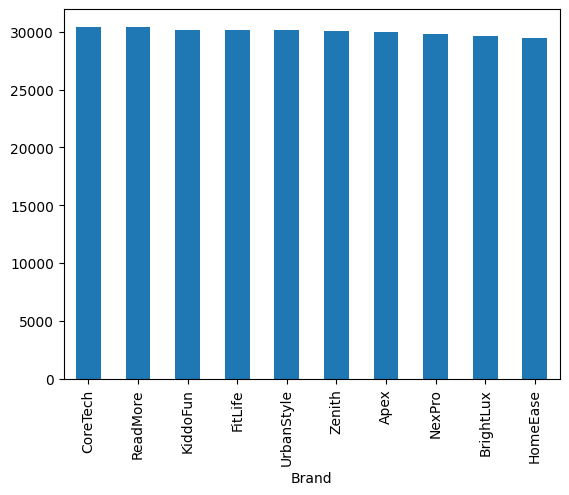

In [ ]:
df_amazon.groupby("Brand")["Quantity"].sum()\
.sort_values(ascending=False).plot(kind="bar")

## **Total amount per category**

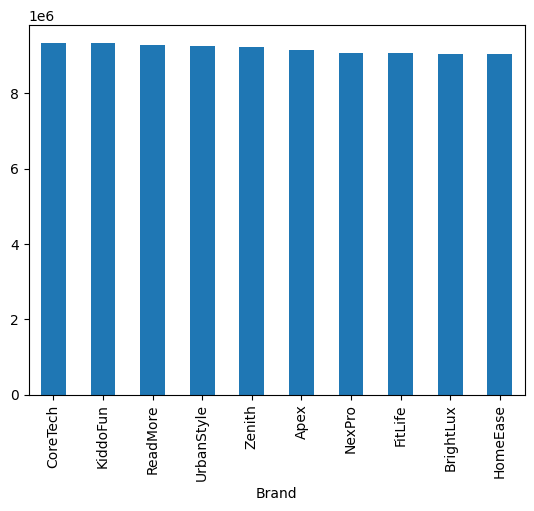

In [ ]:
df_amazon.groupby("Brand")["TotalAmount"].sum()\
.sort_values(ascending=False).plot(kind="bar")
plt.show()

## **Quantity per category**

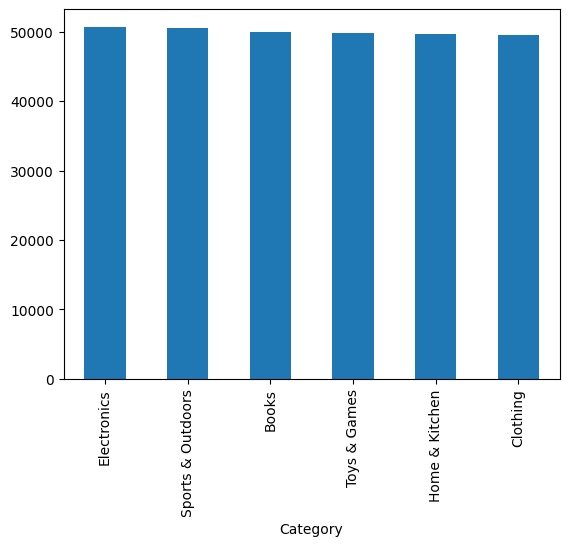

In [ ]:
df_amazon.groupby("Category")["Quantity"].sum()\
.sort_values(ascending=False).plot(kind="bar")
plt.show()

## **Products' highest discount rates**

Highest discount rate product: P00004 -> 8.06%


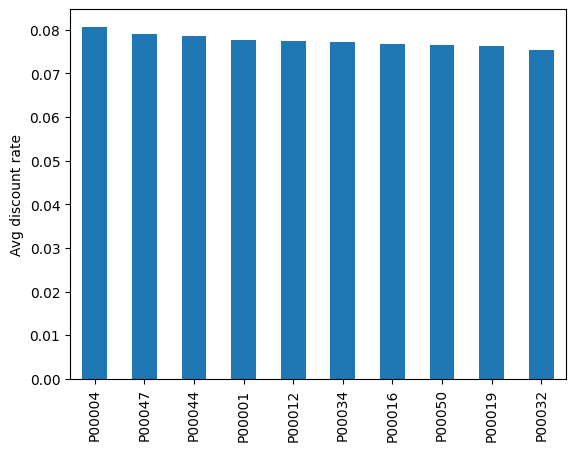

In [ ]:
grouped_product_discount = df_amazon.groupby("ProductID")["Discount"]\
.mean()

grouped_product_discount\
.sort_values(ascending=False)\
.head(10)\
.plot(kind="bar")
plt.xlabel("")
plt.ylabel("Avg discount rate")

print(f"Highest discount rate product: {grouped_product_discount.idxmax()} ->\
{grouped_product_discount[grouped_product_discount.idxmax()]*100: .2f}%")


# **Evolution of the number of orders**

In [ ]:
df_amazon["OrderDate"] = pd.to_datetime(df_amazon["OrderDate"], errors="coerce")

In [ ]:
map_monthName = {1: "January", 2:"February", 3: "March", 4: "April", 5: "May", 6: "June", 7: "July",
                 8: "August", 9: "September", 10: "October", 11: "November", 12: "December"}

month_order = list(map_monthName.values())

df_amazon["OrderMonth"] = df_amazon["OrderDate"].dt.month
df_amazon["OrderMonthName"] = df_amazon["OrderMonth"].map(map_monthName).astype("category").cat.reorder_categories(month_order, ordered=True)
df_amazon["OrderYear"] = df_amazon["OrderDate"].dt.year

In [ ]:
grouped_orders_years_months = df_amazon.groupby(["OrderYear", "OrderMonthName"])["OrderID"].count().reset_index()
grouped_orders_years_months

/tmp/ipython-input-2456235977.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_orders_years_months = df_amazon.groupby(["OrderYear", "OrderMonthName"])["OrderID"].count().reset_index()


,OrderYear,OrderMonthName,OrderID
0,2020,January,1730
1,2020,February,1490
2,2020,March,1685
3,2020,April,1692
4,2020,May,1672
5,2020,June,1633
6,2020,July,1687
7,2020,August,1783
8,2020,September,1679
9,2020,October,1647


Text(0.5, 1.0, 'Number of orders per year')

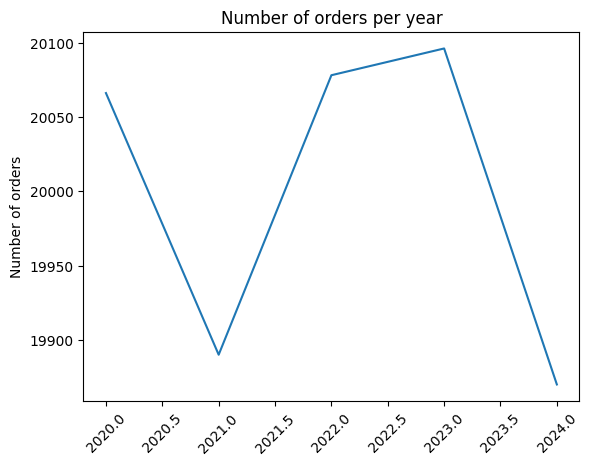

In [ ]:
grouped_orders_years = grouped_orders_years_months.groupby("OrderYear")["OrderID"].sum()

grouped_orders_years.plot()
plt.xticks(rotation=45)
plt.ylabel("Number of orders")
plt.xlabel("")
plt.title("Number of orders per year")

# **Where are the sellers and customers?**

In [ ]:
metrics_sellers_customers_country = {
    "NumberSellers": ("SellerID", "count"),
    "NumberCustomers": ("CustomerID", "count")
}

In [ ]:
grouped_sellers_customers_country = df_amazon.groupby("Country", as_index=False).agg(**metrics_sellers_customers_country)

In [ ]:
df_grouped_sellers_country = grouped_sellers_customers_country.loc[:, ["Country", "NumberSellers"]]

In [ ]:
df_grouped_customers_country = grouped_sellers_customers_country.loc[:, ["Country", "NumberCustomers"]]

In [ ]:
top_sellers_country = df_grouped_sellers_country.sort_values("NumberSellers", ascending=False)

In [ ]:
top_customers_country = df_grouped_customers_country.sort_values("NumberCustomers", ascending=False)

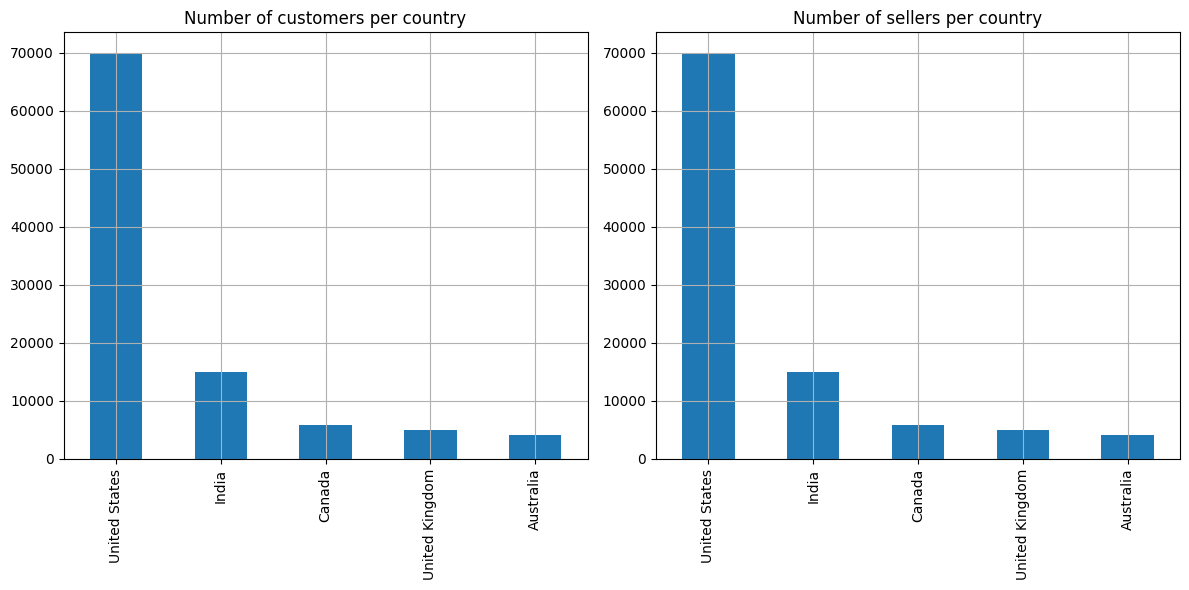

In [ ]:
nrows = 1
ncols = len(metrics_sellers_customers_country)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 6))

top_customers_country.plot(kind="bar", x="Country", ax=axes[0], legend=False)
axes[0].set_title("Number of customers per country")

top_sellers_country.plot(kind="bar", x="Country", ax=axes[1], legend=False)
axes[1].set_title("Number of sellers per country")

for ax in axes:
  ax.set_xlabel("")
  ax.grid(True)

plt.tight_layout()
plt.show()

## **Customers and sellers' performance**

In [ ]:
grouped_sellers_years = df_amazon.groupby("OrderYear")["SellerID"].count()

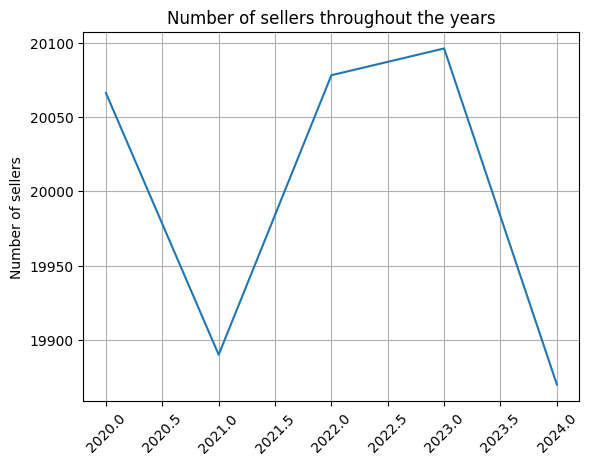

In [ ]:
grouped_sellers_years.plot()
plt.xlabel("")
plt.ylabel("Number of sellers")
plt.xticks(rotation=45)
plt.title("Number of sellers throughout the years")
plt.grid(True)

In [ ]:
grouped_sellers_years_month = df_amazon.groupby(["OrderYear", "OrderMonthName"])[["CustomerID","SellerID"]].count().reset_index()

/tmp/ipython-input-3801347528.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_sellers_years_month = df_amazon.groupby(["OrderYear", "OrderMonthName"])[["CustomerID","SellerID"]].count().reset_index()


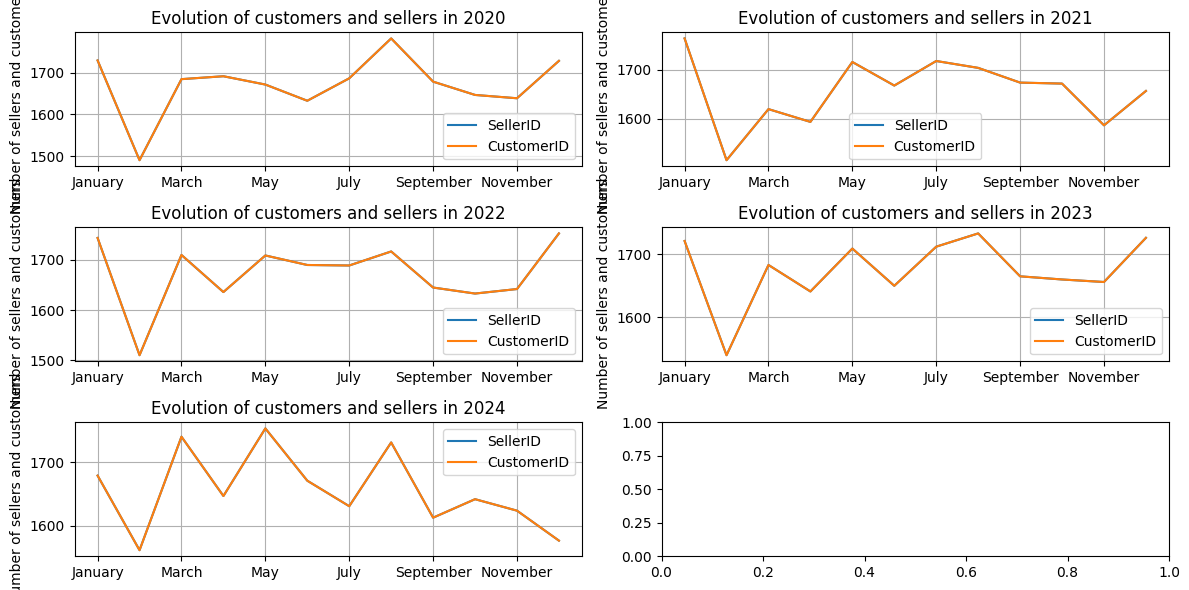

In [ ]:
fig, ax = plt.subplots(3, 2, figsize=(12,6))
ax = ax.flatten()

years = grouped_sellers_years_month["OrderYear"].unique()


for i, year in enumerate(years):
  grouped_sellers_years_month[grouped_sellers_years_month["OrderYear"]==year].plot(x="OrderMonthName", y=["SellerID", "CustomerID"], ax=ax[i])
  ax[i].set_xlabel("")
  ax[i].set_ylabel("Number of sellers and customers")
  ax[i].grid(True)
  ax[i].set_title(f"Evolution of customers and sellers in {year}")
plt.tight_layout()
plt.show()

## **Categorical vs Numerical columns**

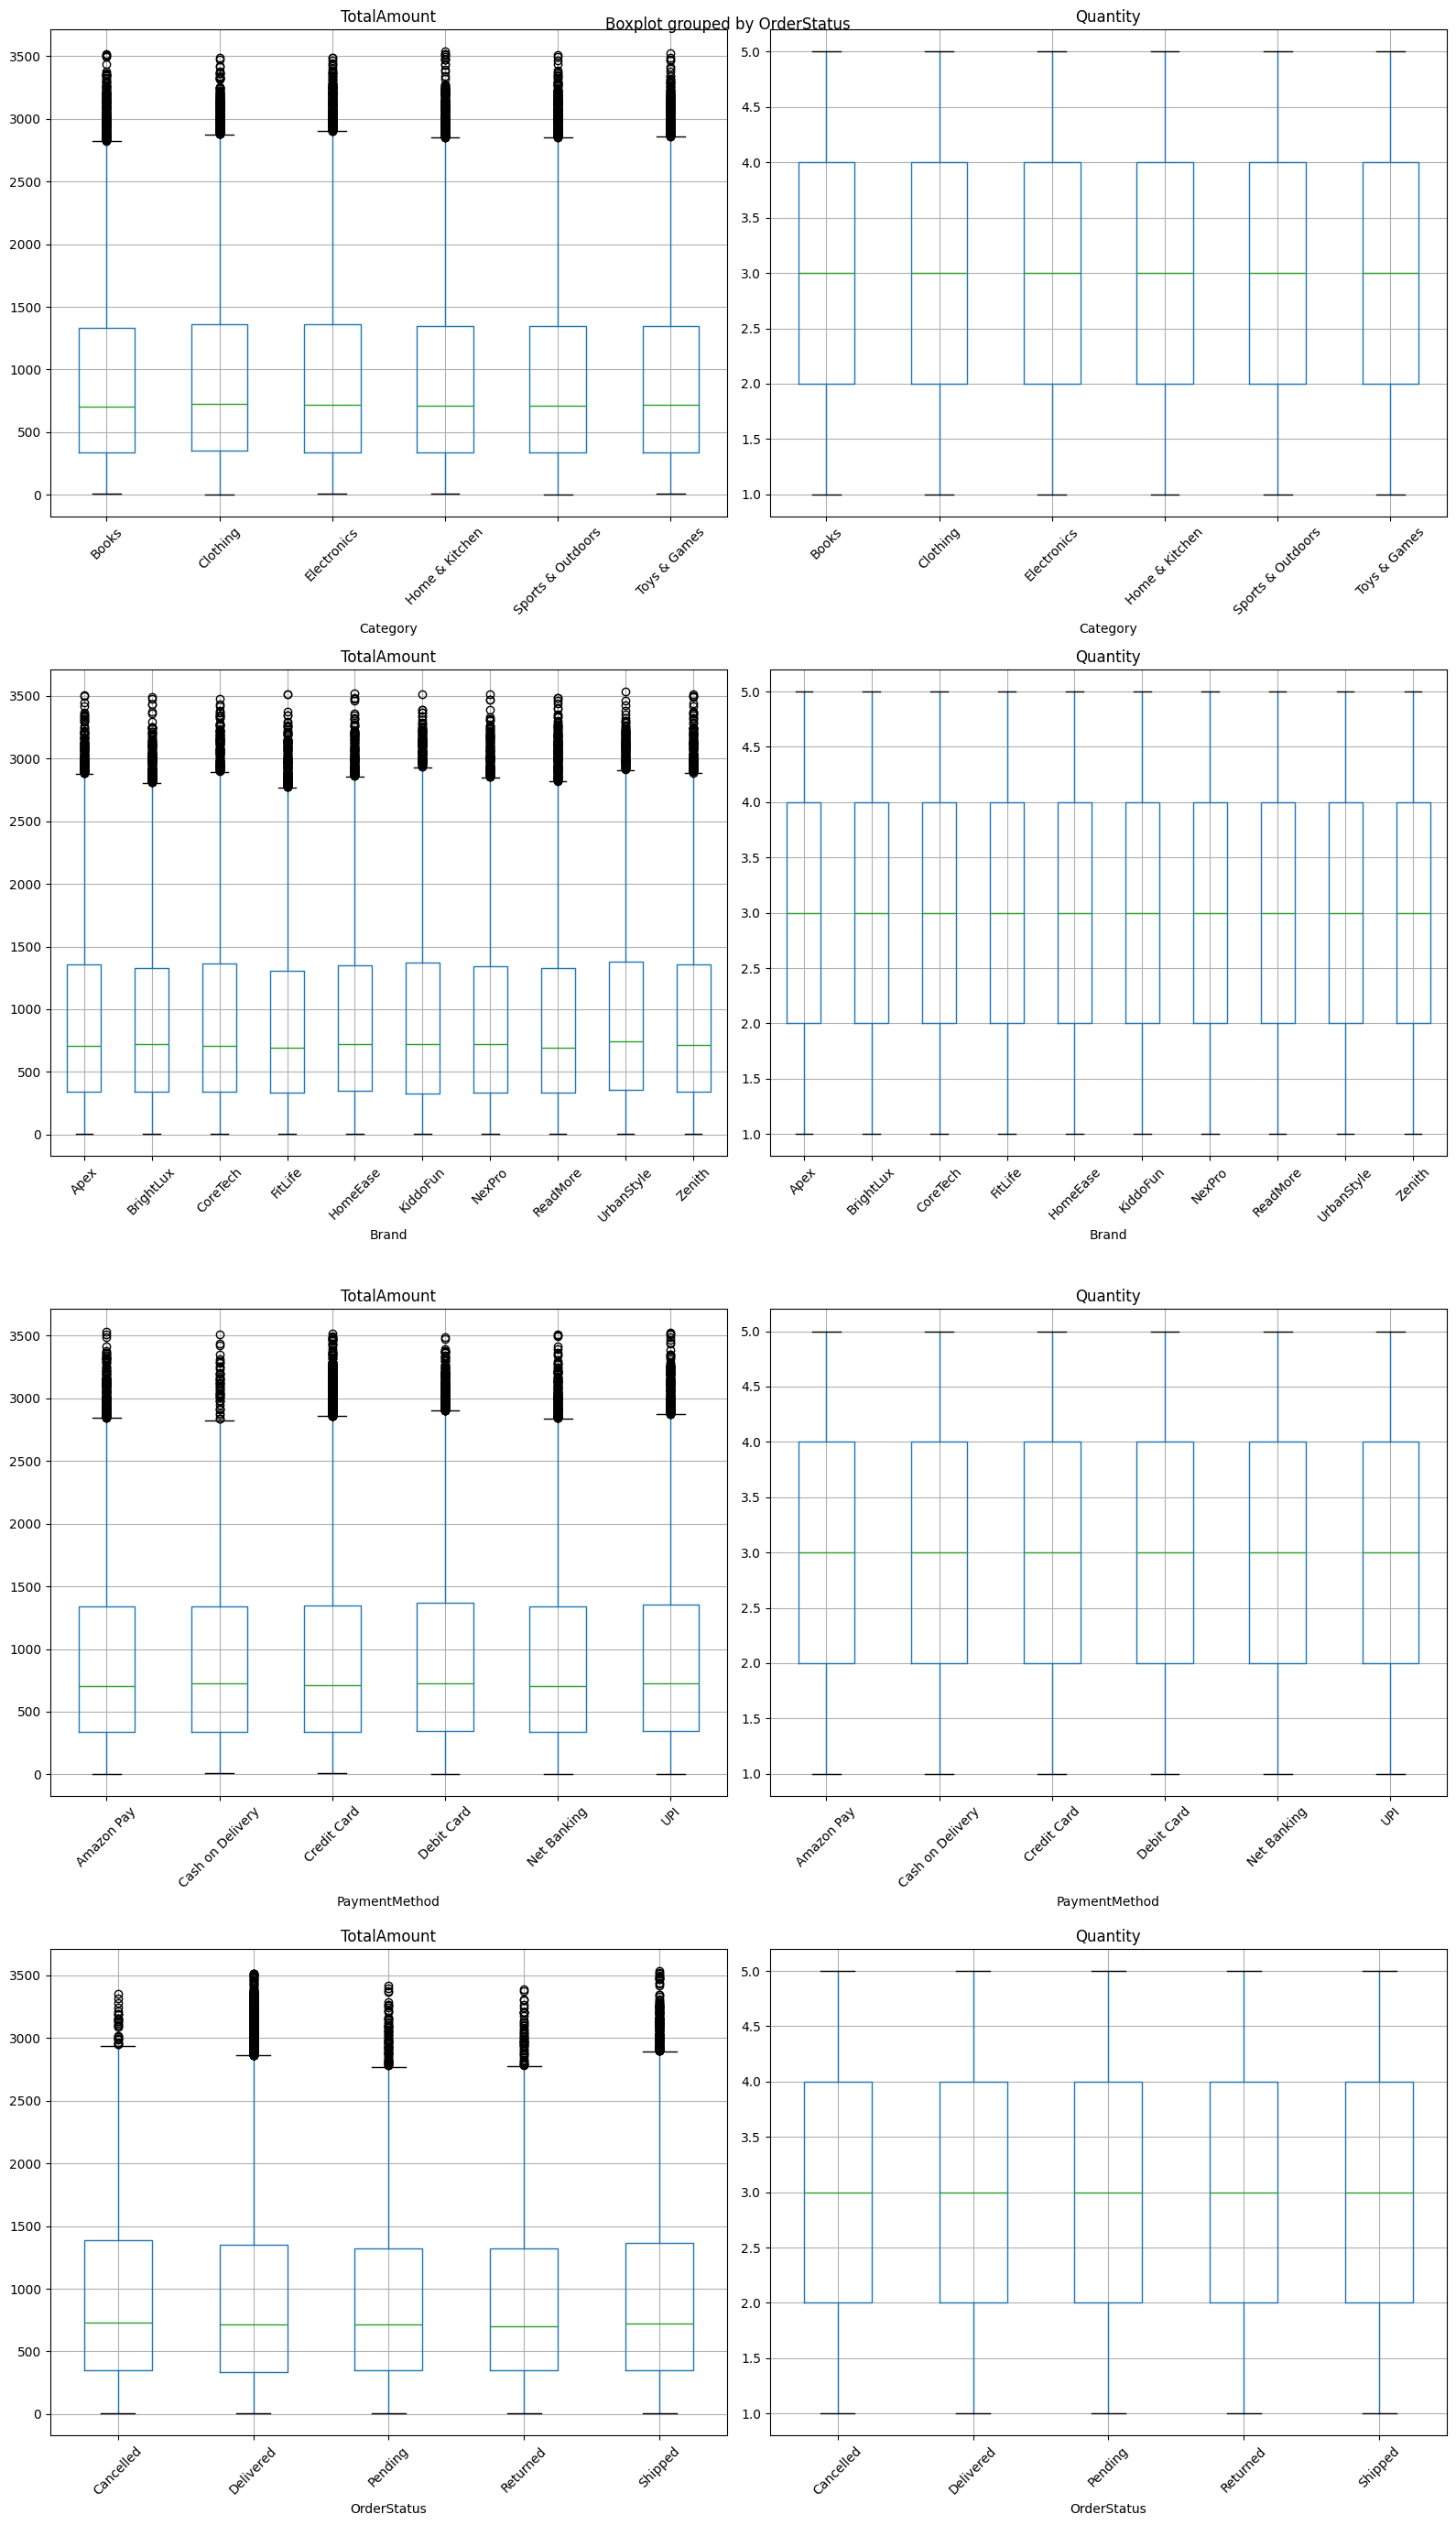

In [ ]:
categorical_columns = ["Category", "Brand", "PaymentMethod", "OrderStatus"]
numerical_columns = ["TotalAmount", "Quantity"]

fig, ax = plt.subplots(len(categorical_columns), len(numerical_columns), figsize=(16, 7 * len(categorical_columns)))

df_amazon[categorical_columns] = df_amazon[categorical_columns].astype("category")

for i, col in enumerate(categorical_columns):
  for j, num in enumerate(numerical_columns):
    df_amazon.boxplot(column=num, by=col, ax=ax[i, j])
    ax[i, j].set_ylabel("")
    ax[i, j].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## **Sales/order distribution by location**

In [ ]:
metrics_orders_city_state = {
    "AvgAmount": ("TotalAmount", "mean"),
    "TotalAmount": ("TotalAmount", "sum"),
    "NumberOrders": ("OrderID", "count")
}

In [ ]:
grouped_orders_city_state = df_amazon.groupby(["State", "City"], as_index=False).agg(**metrics_orders_city_state)
grouped_orders_city_state

,State,City,AvgAmount,TotalAmount,NumberOrders
0,AZ,Phoenix,911.621977,4504324.19,4941
1,CA,Los Angeles,913.529019,4620629.78,5058
2,CA,San Diego,917.709298,4428865.07,4826
3,CA,San Francisco,915.230753,4512087.61,4930
4,CA,San Jose,914.355655,4669614.33,5107
5,CO,Denver,929.372665,4638498.97,4991
6,DC,Washington,900.393569,4520876.11,5021
7,FL,Jacksonville,900.171778,4597177.27,5107
8,IL,Chicago,922.877976,4632847.44,5020
9,IN,Indianapolis,927.373930,4609048.43,4970


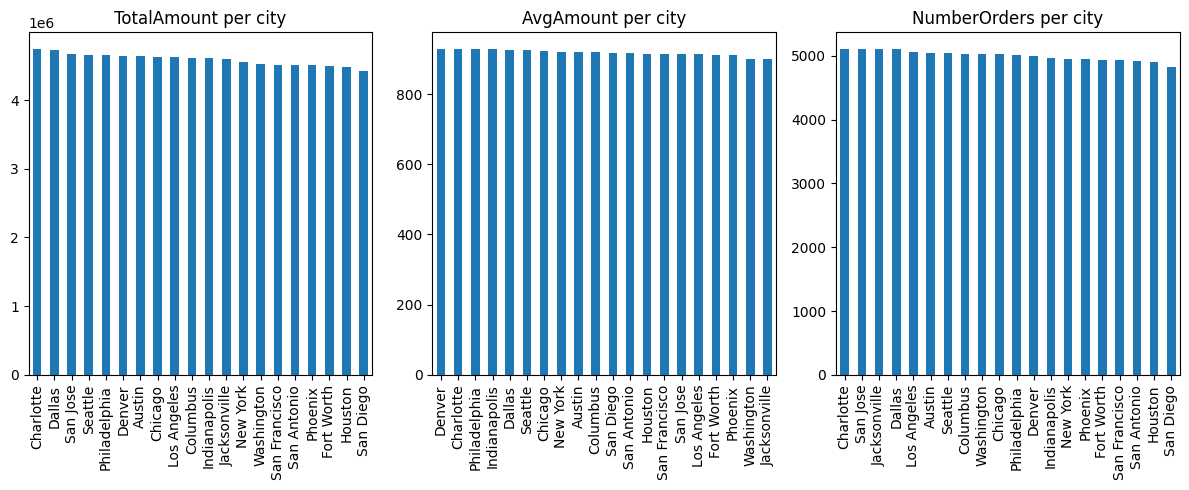

In [ ]:
columns_amount_orders = grouped_orders_city_state[["TotalAmount", "AvgAmount", "NumberOrders"]].columns

fig, ax=plt.subplots(1, len(columns_amount_orders), figsize=(12, 5))

for i, col in enumerate(columns_amount_orders):
  grouped_orders_city_state.sort_values(col, ascending=False)\
  .plot(kind="bar", x="City",
                                 y=col,
                                 ax=ax[i],
                                 legend=False)
  ax[i].set_title(f"{col} per city")
  ax[i].set_xlabel("")
plt.tight_layout()

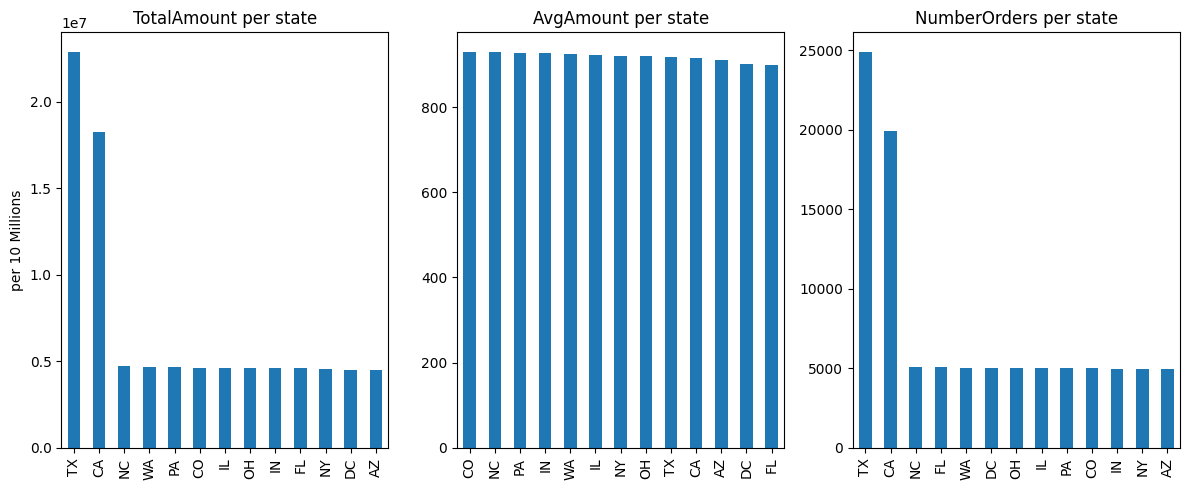

In [ ]:
grouped_orders_state = df_amazon.groupby("State", as_index=False).agg(
    AvgAmount=("TotalAmount", "mean"),
    TotalAmount=("TotalAmount", "sum"),
    NumberOrders=("OrderID", "count")
)

fig, ax=plt.subplots(1, len(columns_amount_orders), figsize=(12, 5))
for i, col in enumerate(columns_amount_orders):
  grouped_orders_state.sort_values(col, ascending=False)\
  .plot(kind="bar", x="State",
                                 y=col,
                                 ax=ax[i],
                                 legend=False)
  ax[i].set_title(f"{col} per state")
  ax[i].set_xlabel("")
  if i==0:
    ax[i].set_ylabel("per 10 Millions")
plt.tight_layout()

Total Amount and number of orders top performer: TX AND CA

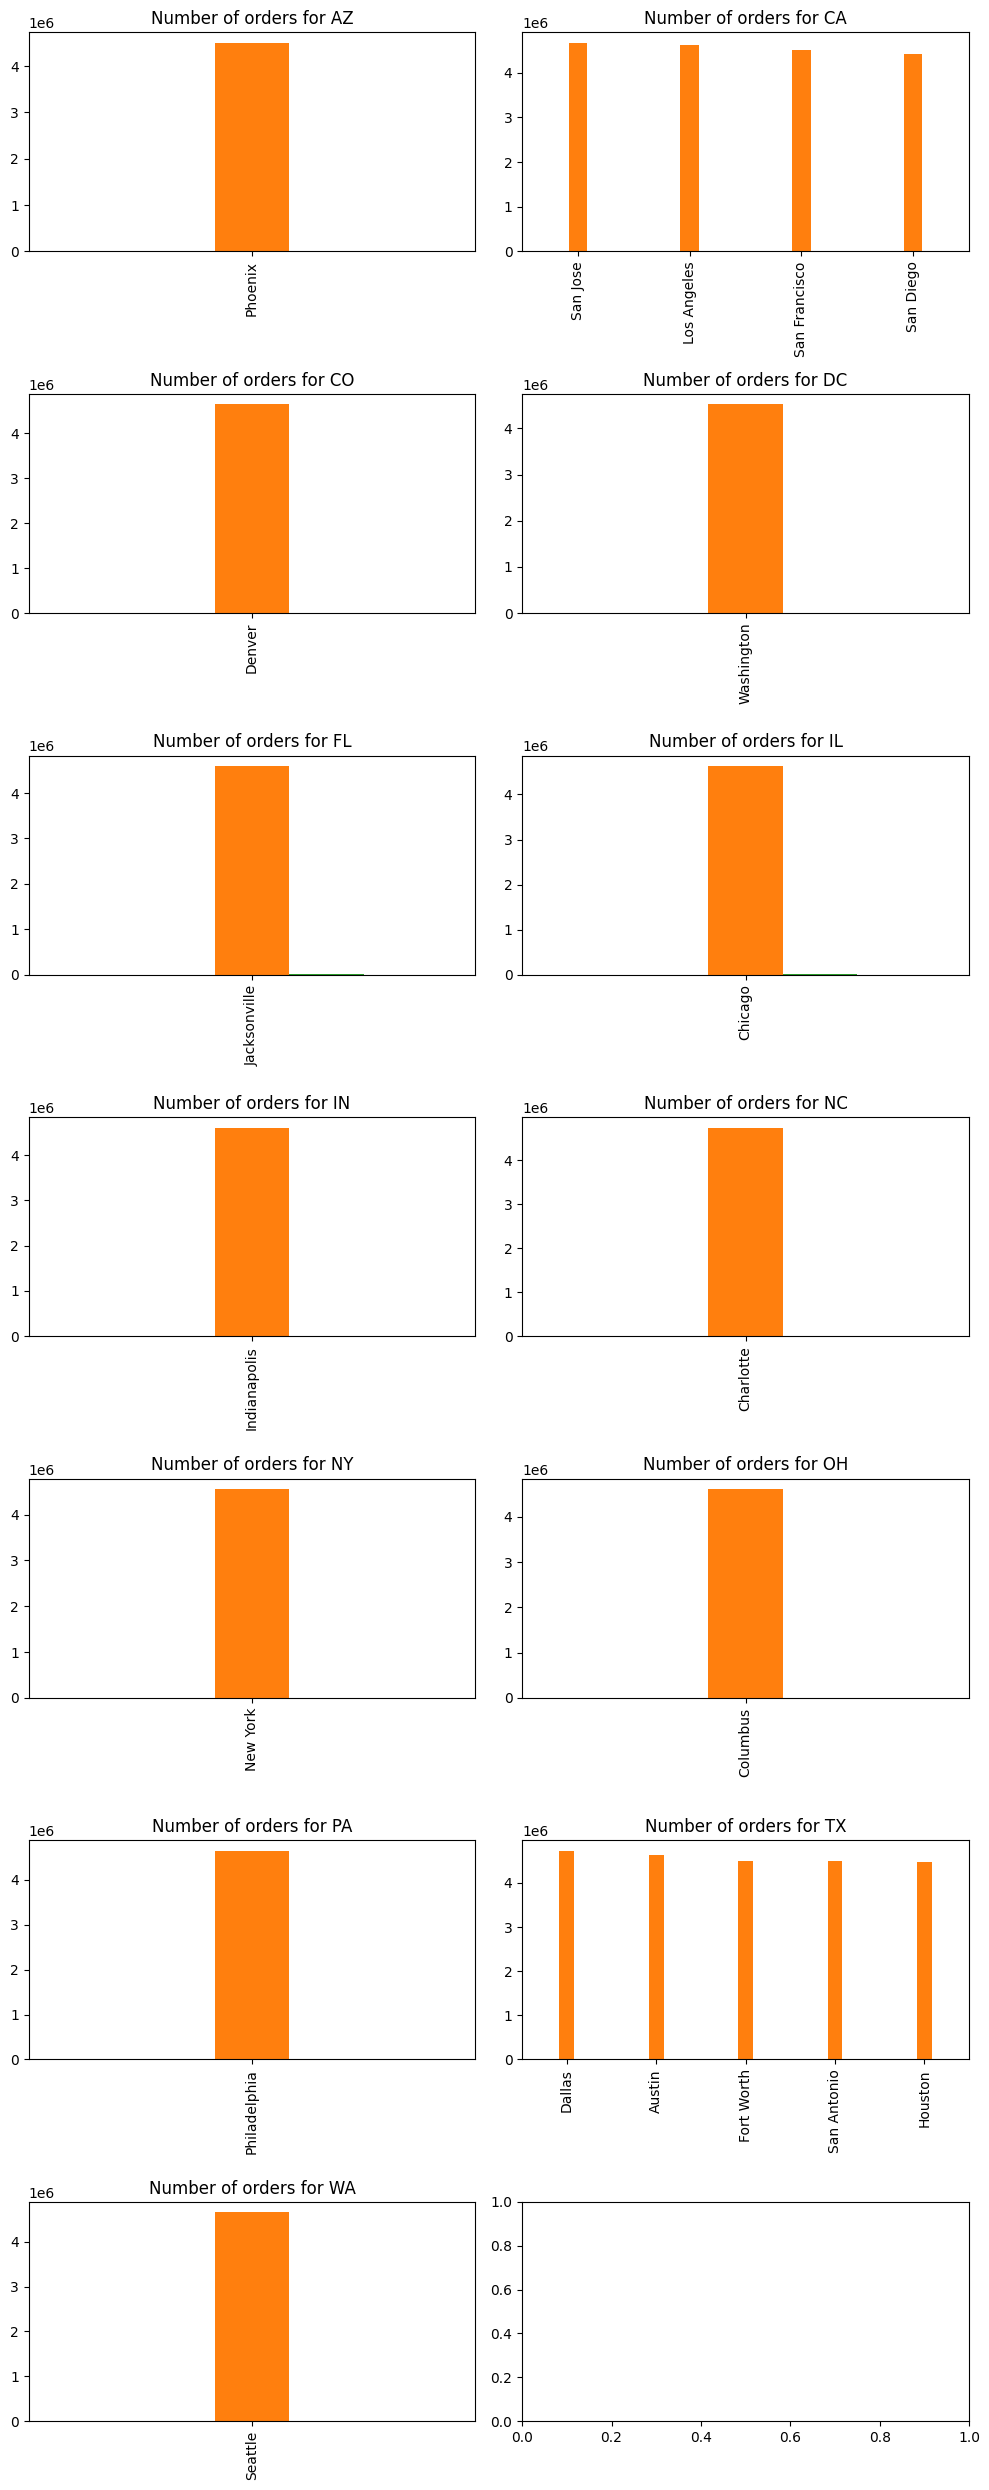

In [ ]:
fig, ax = plt.subplots(7, 2, figsize=(10,25))
ax=ax.flatten()
for i, state in enumerate(grouped_orders_city_state["State"].unique()):
  grouped_orders_city_state[grouped_orders_city_state["State"]==state].sort_values("NumberOrders", ascending=False)\
  .plot(kind="bar", x="City", ax=ax[i], legend=False)
  ax[i].set_title(f"Number of orders for {state}")
  ax[i].set_xlabel("")
plt.tight_layout()

<Axes: >

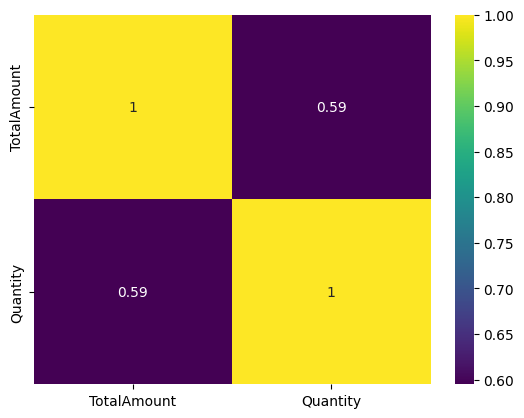

In [ ]:
sns.heatmap(df_amazon[numerical_columns].corr(), annot=True, cmap="viridis")

## **Best customers for average spendings**

<Axes: xlabel='CustomerID'>

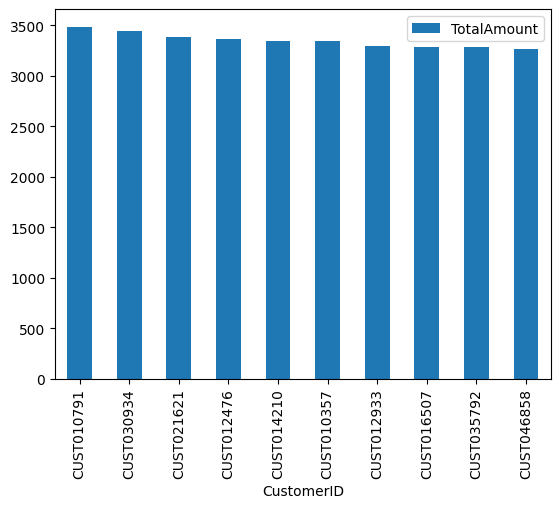

In [ ]:
best_customers_avg_amount = df_amazon.groupby("CustomerID", as_index=False)["TotalAmount"].mean()\
.sort_values("TotalAmount", ascending=False).head(10)
best_customers_avg_amount.plot(kind="bar", x="CustomerID")

## **Highest amount per customer**

<Axes: xlabel='CustomerID'>

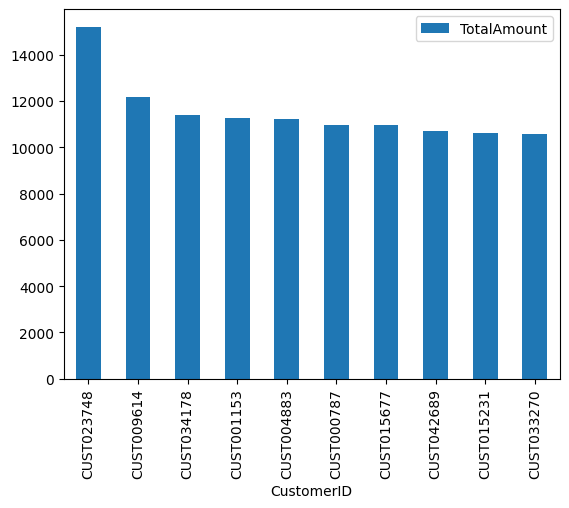

In [ ]:
best_customers_total_amount = df_amazon.groupby("CustomerID", as_index=False)["TotalAmount"].sum()
best_customers_total_amount_srt = best_customers_total_amount.sort_values("TotalAmount", ascending=False).head(10)
best_customers_total_amount_srt.plot(kind="bar", x="CustomerID")

In [ ]:
customers = best_customers_total_amount[best_customers_total_amount["CustomerID"].isin(best_customers_avg_amount["CustomerID"].tolist())]
customers.sort_values("TotalAmount", ascending=False)

,CustomerID,TotalAmount
9306,CUST010791,3484.44
26819,CUST030934,3439.11
18726,CUST021621,3385.69
10791,CUST012476,3366.38
12274,CUST014210,3344.38
8936,CUST010357,3342.39
11193,CUST012933,3290.92
14257,CUST016507,3284.42
30982,CUST035792,3283.13
40529,CUST046858,3265.73


All those customers who has the best avg spendings made only 1 high transaction. That's why data can be biased.

In [ ]:
df_amazon[df_amazon["CustomerID"]=="CUST010791"]

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,...,PaymentMethod,OrderStatus,City,State,Country,SellerID,CalculatedAmount,OrderMonth,OrderMonthName,OrderYear
95290,ORD0095291,2022-04-05,CUST010791,Aman Reddy,P00023,Cookware Set,Electronics,ReadMore,5,589.12,...,UPI,Delivered,Philadelphia,PA,India,SELL01119,3484.44,4,April,2022


## **Payment methods and order status distributions**

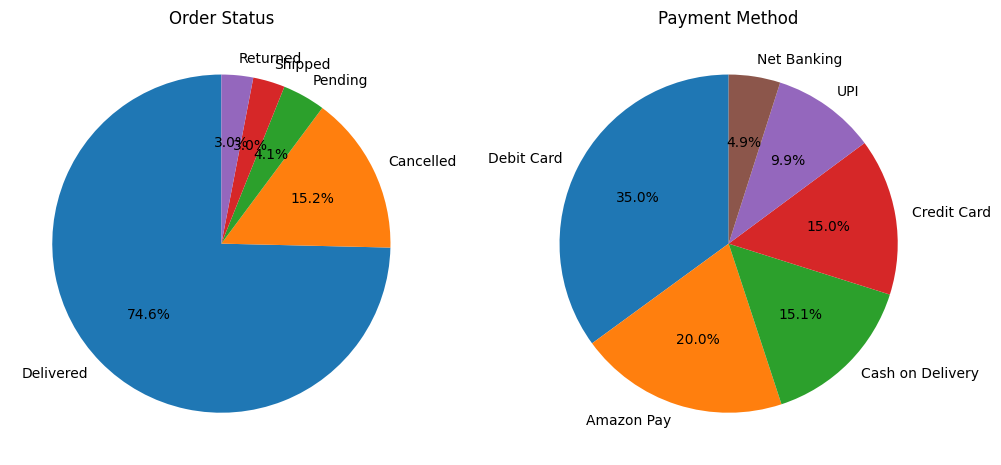

In [ ]:
columns_pie = ["OrderStatus", "PaymentMethod"]
fig, ax=plt.subplots(1, len(columns_pie), figsize=(12, 6))

for i, col in enumerate(columns_pie):
  ax[i].pie(df_amazon[col].value_counts(), labels=df_amazon[col].unique(), autopct="%1.1f%%", startangle=90)
  if i==0:
    ax[i].set_title("Order Status")
  else :
    ax[i].set_title("Payment Method")

**Order Status**: More than 70% of orders are succesfully delivered while approximately, indicating usually a strong fulfilling delivery performance.

**Payment method**: The most commonly used payment method is debit card and payment with amazon pay system. This preference appears to be much more convenient and the second option, may certainly drive to customer incentives or benefits associated with frequent transactions.

# **5. Statistical Tests**

In [ ]:
alpha = 0.05

In [ ]:
def result_hypothesis(pvalue, H0, H1, alpha=0.05):
  if pvalue < alpha:
    print(H1)
  else:
    print(H0)

## **Correlation between Tax and UnitPrice**

- H0: Tax and UnitPrice are not correlated and independent
- H1: Tax and UnitPrice are correlated

In [ ]:
tax_price_columns = ["Tax", "UnitPrice"]

In [ ]:
H0 = "Tax and UnitPrice are not correlated and independent"
H1_positive = "Tax and UnitPrice are correlated positively"
H1_negative = "Tax and UnitPrice are correlated negatively"

How those data are distributed ?

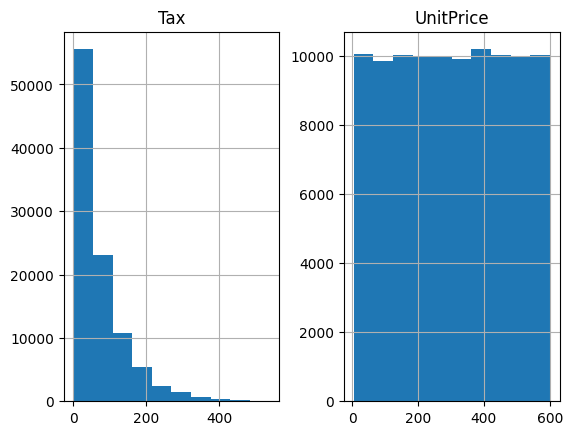

In [ ]:
df_amazon[tax_price_columns].hist()
plt.show()

Tax is not uniformly distributed that means Pearson will be inapropriate because of the outliers

In [ ]:
stats_tax_price, pvalue_tax_price = spearmanr(
    df_amazon["Tax"], df_amazon["UnitPrice"])

In [ ]:
stats_tax_price, pvalue_tax_price

(np.float64(0.5687878510402085), np.float64(0.0))

In [ ]:
if pvalue_tax_price < alpha:
  if stats_tax_price < 0:
    print(H1_negative)
  else:
    print(H1_positive)
else:
  print(H0)

Tax and UnitPrice are correlated positively


The Spearman's rank correlation test confirmed a positive correlation between 'UnitPrice' and 'Tax' with a coefficient of `0.57` and a p-value of `0.0` (which is less than our alpha of 0.05). This means we reject the null hypothesis that they are not correlated.

Therefore, your interpretation is correct: a higher `UnitPrice` is indeed associated with a higher `Tax`.

## **Do payment methods influence the amount the customers are ready to pay?**

- H0: Payment does not influence any amount change
- H1: Payment does influence an amount variation

Let's test if amounts depends on payment methods. So we have two features: one categorical and one numerical. We have 6 independent payment methods so 6 independent groups.
According to the box plot they seem to be equally distributed.
So we can apply ANOVA

Remember also, that thanks to early outliers detection, it does not exists extreme outliers (more than IQR * 3) and this part accounts for only 1,36% of the total. That means ANOVA can be totally appropriate in this case.

In [ ]:
H0= "Payment does not influence any amount change"
H1 = "Payment does influence an amount variation"

/tmp/ipython-input-2900214003.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_amazon.hist(column="TotalAmount", by="PaymentMethod")


<Figure size 1500x700 with 0 Axes>

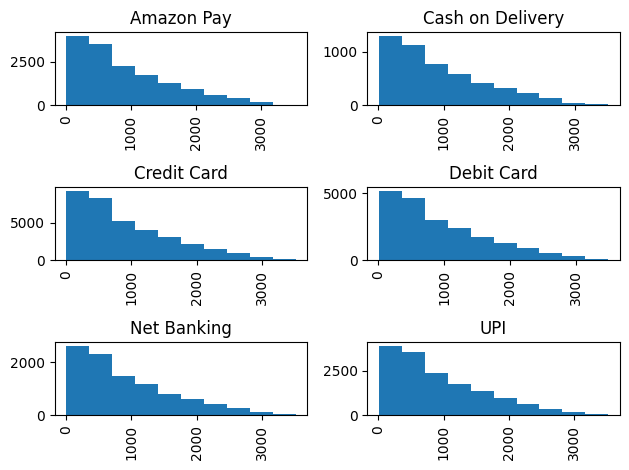

In [ ]:
plt.figure(figsize=(15, 7))
df_amazon.hist(column="TotalAmount", by="PaymentMethod")
plt.xlabel("")
plt.tight_layout()
plt.show()

Kruskal is more accurate than Anova as samples are not well-distributed

In [ ]:
from scipy.stats import f_oneway, kruskal

We store all the groups in a list to be used in the ANOVA

In [ ]:
groups_payment_methods_amount = [
    group["TotalAmount"].values
    for _, group in df_amazon.groupby("PaymentMethod")
]

/tmp/ipython-input-4054147972.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, group in df_amazon.groupby("PaymentMethod")


In [ ]:
stats_payment_methods_amount_kruskal, pvalue_payment_methods_amount_kruskal = kruskal(*groups_payment_methods_amount)
print(stats_payment_methods_amount_kruskal, pvalue_payment_methods_amount_kruskal)

5.472416924892065 0.3609799462761105


In [ ]:
result_hypothesis(pvalue_payment_methods_amount_kruskal, H0, H1)

Payment does not influence any amount change


In [ ]:
stats_payment_methods_amount, pvalue_payment_methods_amount = f_oneway(*groups_payment_methods_amount)
print(stats_payment_methods_amount, pvalue_payment_methods_amount)

0.920906523197526 0.4660251574762493


In [ ]:
result_hypothesis(pvalue_payment_methods_amount, H0, H1)

Payment does not influence any amount change


Based on Anova and Kruskal, there is no significance difference between all the different payement methods with the total amount

In [ ]:
metrics_payment_amount = {
    "MedianAmount":("TotalAmount", "median"),
    "MeanAmount":("TotalAmount", "mean")
}

In [ ]:
df_grouped_payment_amount = df_amazon.groupby("PaymentMethod").agg(**metrics_payment_amount)
df_grouped_payment_amount

/tmp/ipython-input-2337839535.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped_payment_amount = df_amazon.groupby("PaymentMethod").agg(**metrics_payment_amount)


,MedianAmount,MeanAmount
PaymentMethod,,
Amazon Pay,704.970,912.132811
Cash on Delivery,724.170,916.316794
Credit Card,708.195,916.780601
Debit Card,724.800,925.822939
Net Banking,706.350,912.226712
UPI,726.925,922.343592


In [ ]:
min_payment_amount = df_grouped_payment_amount["MedianAmount"].min()
max_payment_amount = df_grouped_payment_amount["MedianAmount"].max()
range_min_max_payment_amount = abs(min_payment_amount - max_payment_amount)
print(f"Range between the max and the min: {range_min_max_payment_amount:.0f}")

Range between the max and the min: 22


The two graphs aboves assess that there is no significative difference between all the payment methods

## **Is there a significant different in the total amount across different Order Status**

let's set up the hypothesis:
- H0: No significant difference in terms of total amount across various order status
- H1: A significance difference in terms of total amont exist across all the order status

In [ ]:
# Groups that belong to the OrderStatus
groups_order_status_amount = [
    group["TotalAmount"].values
    for _, group in df_amazon.groupby("OrderStatus")
]
groups_order_status_amount

/tmp/ipython-input-2698840004.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, group in df_amazon.groupby("OrderStatus")


[array([ 821.36,  268.9 , 2367.55, ...,   36.74,  102.29, 1539.73]),
 array([ 319.86,  259.64,  108.06, ..., 1016.4 ,  330.66,  858.52]),
 array([ 617.73, 1286.86, 1236.26, ...,  641.94,  160.1 ,  601.55]),
 array([2968.03,  226.77, 1871.76, ...,   20.78, 2114.  ,  166.55]),
 array([1791.23, 1766.23,  485.18, ...,   20.82, 2488.17,  956.02])]

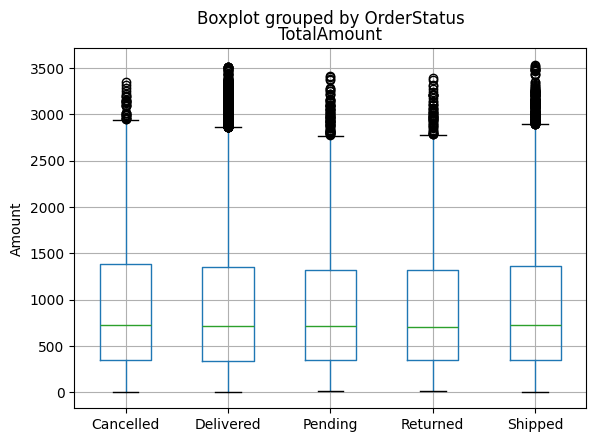

In [ ]:
df_amazon.boxplot(
    column="TotalAmount",
    by="OrderStatus")
plt.xlabel("")
plt.ylabel("Amount")
plt.show()

/tmp/ipython-input-1210691158.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_amazon.hist(column="TotalAmount", by="OrderStatus")


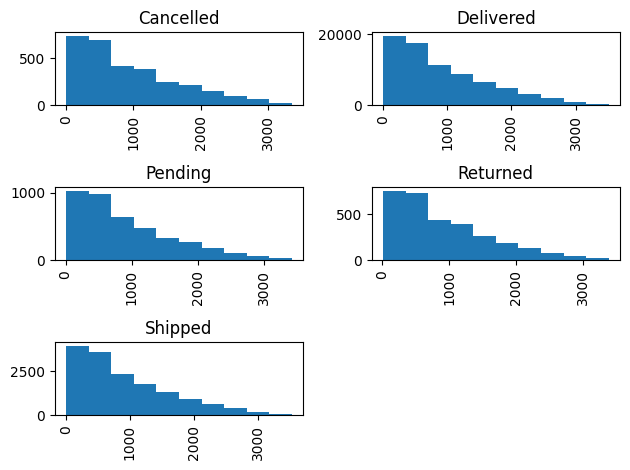

In [ ]:
df_amazon.hist(column="TotalAmount", by="OrderStatus")
plt.tight_layout()

The distribution seem to be skewed but let's check how skewed the data currently are

Let's check about median and mean amount to see how far those values range

In [ ]:
metrics_order_status_amount = metrics_payment_amount

In [ ]:
df_outliers_order_status_amount = df_amazon[outliers_rs]

/tmp/ipython-input-264439955.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_outliers_order_status_amount.plot(kind="box", by="OrderStatus", column="TotalAmount")


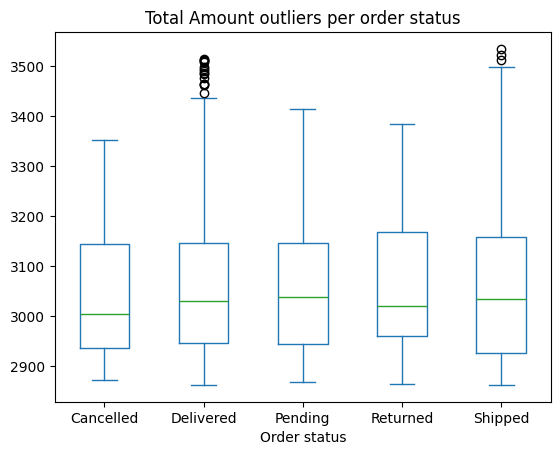

In [ ]:
df_outliers_order_status_amount.plot(kind="box", by="OrderStatus", column="TotalAmount")
plt.title("Total Amount outliers per order status")
plt.xlabel("Order status")
plt.show()

In [ ]:
outliers_order_status_amount_rate = outliers_rs.sum() / df_amazon["TotalAmount"].count()

Visually, some outliers exist

There are significant sample size to be considered as a valid ANOVA test. The groups seem to not vary significantly

In [ ]:
df_amazon.groupby("OrderStatus").agg(**metrics_order_status_amount)

/tmp/ipython-input-3561583572.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_amazon.groupby("OrderStatus").agg(**metrics_order_status_amount)


,MedianAmount,MeanAmount
OrderStatus,,
Cancelled,730.480,941.585994
Delivered,712.315,916.179947
Pending,717.340,910.932727
Returned,703.950,911.991623
Shipped,721.530,927.042456


In [ ]:
groups_order_status_amount_arr = [np.log1p(np.array(g)) for g in groups_order_status_amount]

In [ ]:
groups_order_status_amount_arr

[array([6.71217826, 5.59805152, 7.77003323, ..., 3.63072054, 4.63754057,
        7.34001161]),
 array([5.77100489, 5.56314014, 4.69189819, ..., 6.92500563, 5.80411035,
        6.75637409]),
 array([6.42766899, 7.16073721, 7.12065454, ..., 6.46605141, 5.08202529,
        6.40117065]),
 array([7.99599058, 5.42833635, 7.53516856, ..., 3.08099212, 7.65681009,
        5.12128181]),
 array([7.49121593, 7.47716863, 6.18657893, ..., 3.08282698, 7.8197046 ,
        6.86382429])]

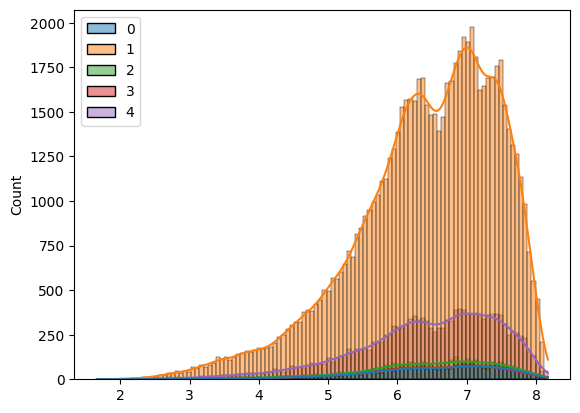

In [ ]:
sns.histplot(groups_order_status_amount_arr, kde=True)
plt.show()

In [ ]:
list_orders = []
for i, order in enumerate(df_amazon["OrderStatus"].unique()):
  name = f"order_{i}"
  name = df_amazon[df_amazon["OrderStatus"] == order]["TotalAmount"]
  list_orders.append(name)

No significant difference between all the order status

In [ ]:
anova, pvalue = f_oneway(*groups_order_status_amount)
print(pvalue)

0.15653609580768071


In [ ]:
anova, pvalue = f_oneway(*groups_order_status_amount_arr)
print(pvalue)

0.21011367153311808


In [ ]:
from scipy.stats import kruskal

krus, pvalue = kruskal(*list_orders)
print(krus)
print(f"pvalue: {pvalue}")

4.950094454592042
pvalue: 0.2924565536762193


According to Kruskal's test, there is no signficant difference across all the order status. So as per conclude, we cannot reject the null hypothesis.

## **Is there a difference between order status in terms of quantity**

let's set up the hypothesis:

- H0: No significant difference in terms of quantity across various order status
- H1: A significance difference in terms of quantity exist across all the order status

In [ ]:
H0= "No significant difference in terms of quantity across various order status"
H1= "A significance difference in terms of quantity exist across all the order status"

/tmp/ipython-input-2602788079.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_amazon.hist(column="Quantity", by="OrderStatus")


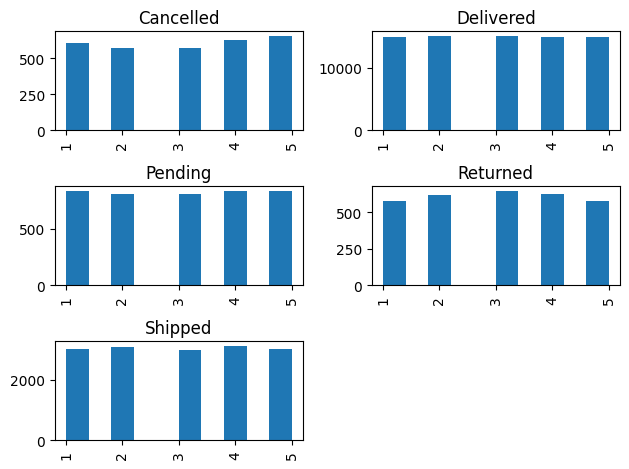

In [ ]:
df_amazon.hist(column="Quantity", by="OrderStatus")
plt.tight_layout()

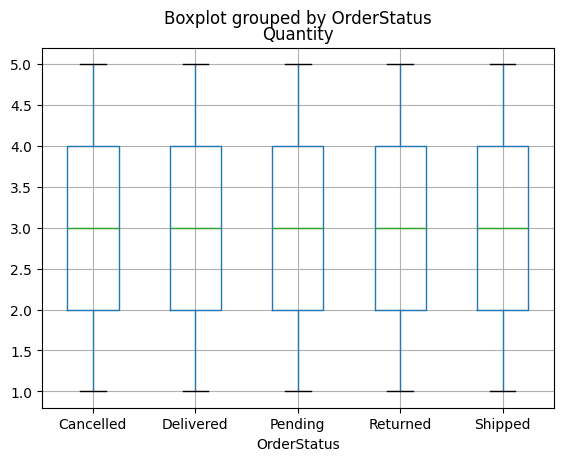

In [ ]:
df_amazon.boxplot(column="Quantity", by="OrderStatus")
plt.show()

In [ ]:
df_amazon.groupby("OrderStatus")["Quantity"].agg("mean")

/tmp/ipython-input-1744142997.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_amazon.groupby("OrderStatus")["Quantity"].agg("mean")


,Quantity
OrderStatus,
Cancelled,3.052180
Delivered,2.998325
Pending,3.007068
Returned,2.998032
Shipped,3.005529


In [ ]:
groups_order_status_quantity = [
    group["Quantity"].values
    for _, group in df_amazon.groupby("OrderStatus")
]

/tmp/ipython-input-178839822.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, group in df_amazon.groupby("OrderStatus")


In [ ]:
ano, pvalue = f_oneway(*groups_order_status_quantity)

print(ano)
print(f"pvalue: {pvalue}")

1.118431681798031
pvalue: 0.3456807974085564


In [ ]:
if pvalue < alpha:
  print(H1)
else:
  print(H0)

No significant difference in terms of quantity across various order status


Failure to reject the null hypothesis: no significant differences between across all the methods. No relevant strategy to put on a specific wether it is the quantity or the total amount

## **Does a payment method is independent of their order status**?

- H0: PaymentMethod and OrderStatus are independent (no relationship between them)
- H1: PaymentMethod and OrderStatus are not independent

In [ ]:
H0= "PaymentMethod and OrderStatus are independent (no relationship between them)"
H1= "PaymentMethod and OrderStatus are associated"

In [ ]:
method_order = pd.crosstab(df_amazon["OrderStatus"], df_amazon["PaymentMethod"])
method_order

PaymentMethod,Amazon Pay,Cash on Delivery,Credit Card,Debit Card,Net Banking,UPI
OrderStatus,,,,,,
Cancelled,461,156,1083,593,291,444
Delivered,11251,3633,26073,14917,7406,11348
Pending,585,196,1471,832,417,602
Returned,472,143,1075,609,313,437
Shipped,2248,800,5336,3073,1500,2235


In [ ]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(method_order)

print(chi2)
print(f"p: {p}")
print(f"Expected: {expected}")

14.993730738505967
p: 0.7767662291918548
Expected: [[  454.71476   149.21984  1060.95064   606.32672   300.58956   456.19848]
 [11206.88676  3677.66784 26148.15864 14943.51072  7408.32156 11243.45448]
 [  616.14751   202.19584  1437.60914   821.58472   407.30481   618.15798]
 [  457.86833   150.25472  1068.30862   610.53176   302.67423   459.36234]
 [ 2281.38264   748.66176  5322.97296  3042.04608  1508.10984  2288.82672]]


In [ ]:
df_expected = pd.DataFrame(
    data=expected,
    columns=method_order.columns,
    index=method_order.index)
df_expected

PaymentMethod,Amazon Pay,Cash on Delivery,Credit Card,Debit Card,Net Banking,UPI
OrderStatus,,,,,,
Cancelled,454.71476,149.21984,1060.95064,606.32672,300.58956,456.19848
Delivered,11206.88676,3677.66784,26148.15864,14943.51072,7408.32156,11243.45448
Pending,616.14751,202.19584,1437.60914,821.58472,407.30481,618.15798
Returned,457.86833,150.25472,1068.30862,610.53176,302.67423,459.36234
Shipped,2281.38264,748.66176,5322.97296,3042.04608,1508.10984,2288.82672


In [ ]:
if p < alpha:
  print(H1)
else:
  print(H0)

PaymentMethod and OrderStatus are independent (no relationship between them)


According to the test, no significant association with a pvalue < 0.05. Hence, we fail to reject the null hypothesis

We want to calculate the residuals to visually monitor all the associations.
residual > 2: strong association

In [ ]:
residuals = (method_order - expected) / np.sqrt(expected)

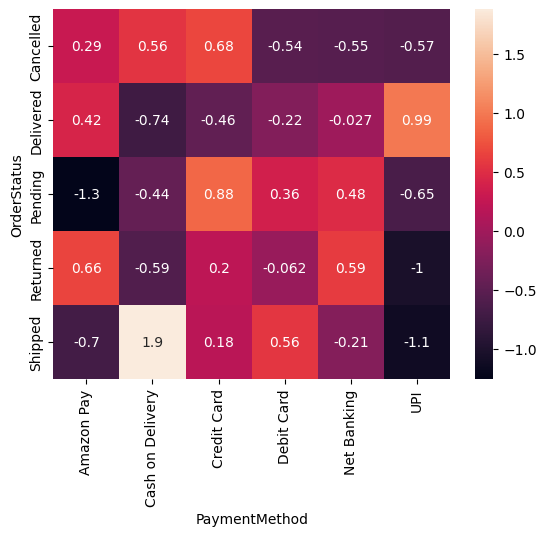

In [ ]:
sns.heatmap(residuals, annot=True)
plt.show()

Visualisation states a clear outlook of non-associated values because no residuals > 2.

After analysis, we observe that some customers have a higher average spend because they made a single high-value purchase whereas others have a higher total spend but a lower average because they completed many more transactions.

Therefore, comparing both metrics is essential to gain a more accurate overall view and avoid being misled by interpretation bias.

In [ ]:
df_amazon[df_amazon["CustomerID"]=="CUST023748"]

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,...,PaymentMethod,OrderStatus,City,State,Country,SellerID,CalculatedAmount,OrderMonth,OrderMonthName,OrderYear
10494,ORD0010495,2021-08-23,CUST023748,Vivaan Verma,P00046,Car Charger,Toys & Games,CoreTech,2,422.25,...,Debit Card,Delivered,Houston,TX,United States,SELL00862,999.970000,8,August,2021
27761,ORD0027762,2024-11-05,CUST023748,Sahil Joshi,P00043,HDMI Cable 2m,Books,KiddoFun,5,471.98,...,Debit Card,Shipped,San Antonio,TX,United States,SELL00647,2360.304762,11,November,2024
27985,ORD0027986,2024-01-10,CUST023748,Mohit Kapoor,P00003,Smartphone Case,Home & Kitchen,Zenith,4,296.04,...,Credit Card,Shipped,San Jose,CA,United States,SELL01627,1141.608696,1,January,2024
43544,ORD0043545,2024-06-02,CUST023748,Vikas Sharma,P00030,Dress Shirt,Electronics,HomeEase,5,538.27,...,Net Banking,Delivered,San Diego,CA,United States,SELL01192,3018.830000,6,June,2024
52967,ORD0052968,2024-10-09,CUST023748,Aman Gupta,P00026,Sunglasses,Home & Kitchen,Apex,3,344.11,...,Credit Card,Delivered,Houston,TX,United States,SELL01457,920.308333,10,October,2024
58943,ORD0058944,2021-07-01,CUST023748,Sahil Sharma,P00010,Smartwatch,Sports & Outdoors,KiddoFun,1,331.40,...,Amazon Pay,Pending,Chicago,IL,Canada,SELL00403,338.847619,7,July,2021
63813,ORD0063814,2024-04-08,CUST023748,Vikas Gupta,P00016,Air Fryer,Toys & Games,NexPro,4,598.63,...,UPI,Shipped,Denver,CO,United States,SELL01835,2596.580000,4,April,2024
64974,ORD0064975,2021-11-15,CUST023748,Kabir Patel,P00040,Microphone,Sports & Outdoors,NexPro,2,211.26,...,Credit Card,Shipped,Indianapolis,IN,United States,SELL00170,353.075000,11,November,2021
67033,ORD0067034,2022-04-04,CUST023748,Rohit Reddy,P00014,Drone Mini,Sports & Outdoors,Zenith,5,578.86,...,Credit Card,Delivered,Denver,CO,United States,SELL00969,3140.610000,4,April,2022
76409,ORD0076410,2020-01-22,CUST023748,Vihaan Mehta,P00019,LED Desk Lamp,Electronics,FitLife,2,201.85,...,Net Banking,Delivered,Washington,DC,United States,SELL00884,389.363636,1,January,2020


# **7. Results & Interpretation**

## **Predict Total Amount based on numerical values**

In [ ]:
based_features_prediction = ["Quantity",
                             "UnitPrice",
                             "Discount",
                             "Tax",
                             "ShippingCost",
                             "TotalAmount"]
df_amazon.loc[:, based_features_prediction].head()

,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
0,3,106.59,0.00,0.00,0.09,319.86
1,1,251.37,0.05,19.10,1.74,259.64
2,3,35.03,0.10,7.57,5.91,108.06
3,5,33.58,0.15,11.42,5.53,159.66
4,2,515.64,0.25,38.67,9.23,821.36


In [ ]:
mean_median = df_amazon.loc[:, based_features_prediction].describe().loc[
    df_amazon.loc[:, based_features_prediction].describe().index.isin(["mean", "50%"])
]

As observed earlier, no extreme outliers has been observed, that allows to get median and mean values closer to each other. Then, models either based on mean values or median values can be used without taking the risk to be distorted.

Total amount and all the numerical features can be calculated, so normally there won't need any model.
But for academical purposes, let's just perform some prediction models, just to confirm this assumption.

Better to standardize those features

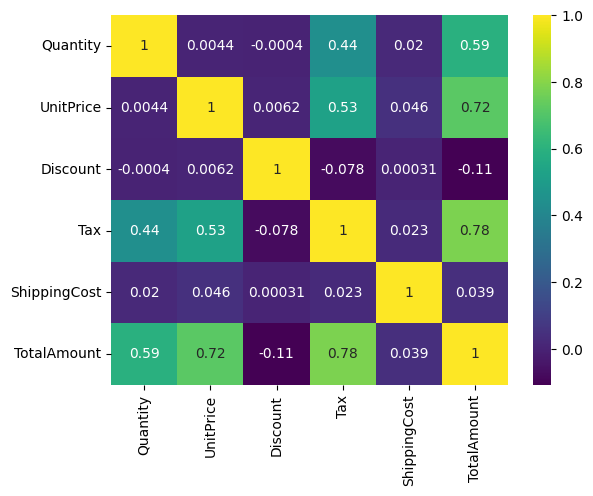

In [ ]:
sns.heatmap(df_amazon[based_features_prediction].corr(),
            annot=True, cmap="viridis")
plt.show()


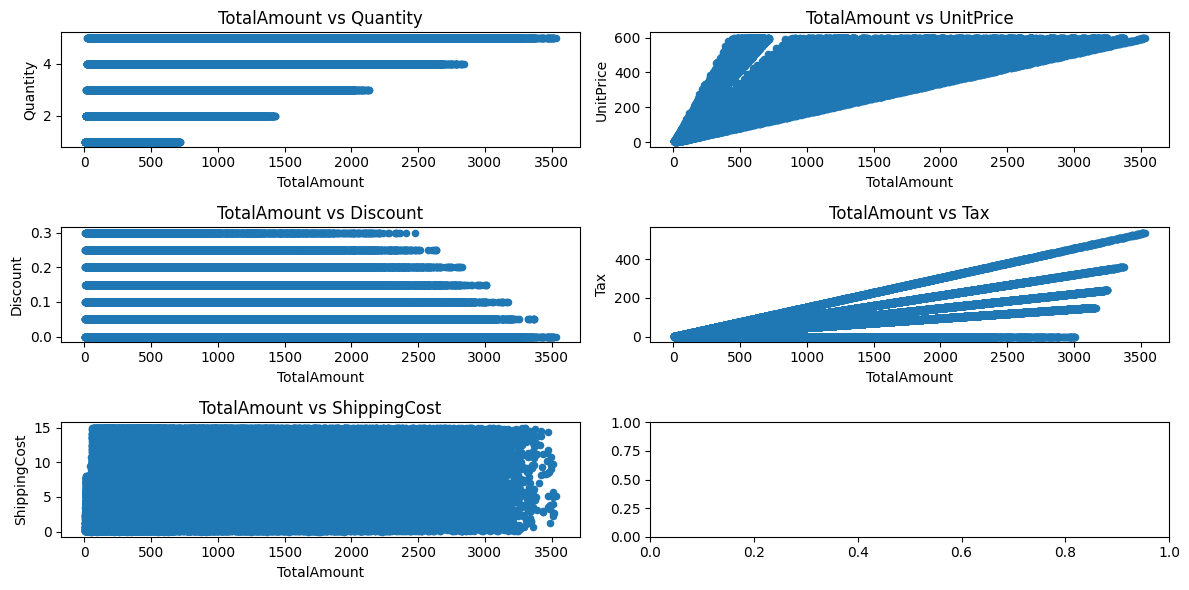

In [ ]:
ncols=2
nrows = math.ceil(len(based_features_prediction[:-1]) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 6))
axes = axes.flatten()

# We don't include the total Amount in our columns
for i, col in enumerate(based_features_prediction[:-1]):
  df_amazon.plot(kind="scatter", x="TotalAmount", y=col, ax=axes[i])
  axes[i].set_title(f"TotalAmount vs {col}")
plt.tight_layout()
plt.show()

In [ ]:
# Let's build our linear regression predicted model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score

In [ ]:
models = {
    "linearReg": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "randomForestRegressor": Pipeline([
        ("model", RandomForestRegressor())
    ])
}

In [ ]:
X = df_amazon[based_features_prediction].drop("TotalAmount", axis=1)
target = df_amazon["TotalAmount"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, target, test_size=0.3, random_state=42)

In [ ]:
pipeline_lr = models["linearReg"]
training_score_linear_regression = cross_val_score(pipeline_lr, X_train, y_train, cv=5, scoring="r2")

In [ ]:
best_training_score_linear_regression = max(training_score_linear_regression)
print(f"The model predict with {best_training_score_linear_regression*100:.0f}% of accuracy on the training dataset")

The model predict with 91% of accuracy on the training dataset


In [ ]:
pipeline_lr.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

In [ ]:
y_pred = pipeline_lr.predict(X_test)
r2score_linreg = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"R2 score: {r2score_linreg*100:.2f}%")
print(f"MSE score: {mse:.0f}")
print(f"MAE score: {mae:.0f}")

R2 score: 90.96%
MSE score: 47398
MAE score: 166


In [ ]:
print(
    f"Training dataset : {best_training_score_linear_regression:.2f} - "
    f"Test dataset: {r2score_linreg:.2f}"
)

Training dataset : 0.91 - Test dataset: 0.91


The model predicted the same high score over both training and test datasets. That means the model is quite robust.

In [ ]:
df_prediction_reals = pd.DataFrame({
    "predictions": y_pred,
    "reals": y_test
})

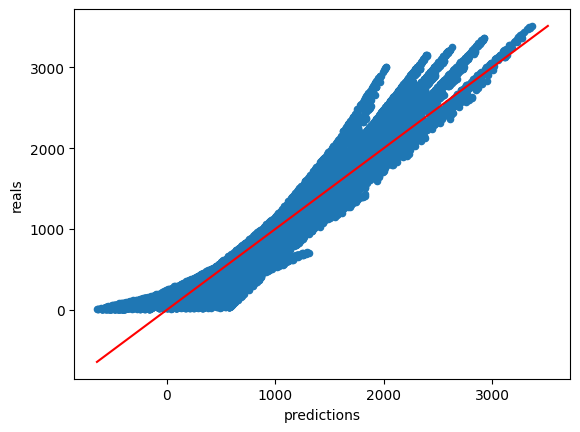

In [ ]:
df_prediction_reals.plot(kind="scatter", x="predictions", y="reals")
min_val = min(min(y_pred), min(y_test))
max_val = max(max(y_pred), max(y_test))
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red")
plt.show()

Let's try another regressor model to see if the score can be higher and then more robust for future predictions

In [ ]:
from sklearn.ensemble import RandomForestRegressor

pipeline_rf = models["randomForestRegressor"]
pipeline_rf.set_params(
    model__n_estimators = 100,
    model__n_jobs = -1,
    model__random_state = 42
)

cross_score_rff = cross_val_score(pipeline_rf, X_train, y_train, cv=5, scoring="r2")

In [ ]:
best_cross_score_rff = max(cross_score_rff)
best_cross_score_rff

np.float64(0.9999332337211856)

In [ ]:
pipeline_rf.fit(X_train, y_train)

Pipeline(steps=[('model', RandomForestRegressor(n_jobs=-1, random_state=42))])

In [ ]:
y_pred = pipeline_rf.predict(X_test)
r2score_rff = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"R2 score: {r2score_rff*100:.2f}%")
print(f"MSE score: {mse:.0f}")
print(f"MAE score: {mae:.0f}")

R2 score: 99.99%
MSE score: 32
MAE score: 3


In [ ]:
print(
    f"Training dataset : {best_cross_score_rff:.2f} - "
    f"Test dataset: {r2score_rff:.2f}"
)

Training dataset : 1.00 - Test dataset: 1.00


Model fits perfectly, better than the previous one, as both results are good. That means, no risks of underfitting or overfitting.

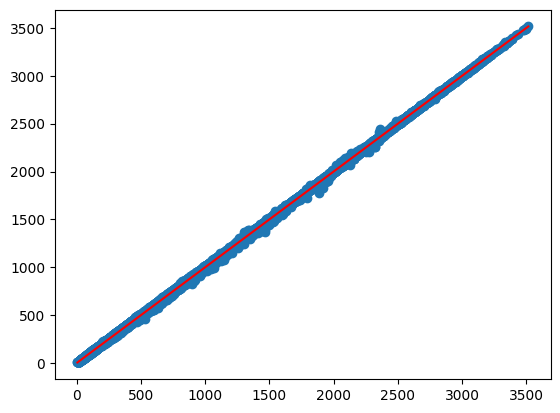

In [ ]:
plt.scatter(x=y_pred, y=y_test)
min_val = min(min(y_pred), min(y_test))
max_val = max(max(y_pred), max(y_test))
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red")
plt.show()